In [45]:
import numpy as np
import random
from sklearn.datasets import load_iris
from sklearn.metrics import silhouette_score
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
def rast(x,y):
    res = 0
    for i in range(x.shape[0]):
        res += (x[i] - y[i]) ** 2
    return res ** 0.5
def show(dataset,clusters):
    l = np.zeros(dataset.shape[0])
    cur = 1
    for i in clusters.keys():
        for j in clusters[i]:
            l[j] = cur
        cur += 1
    df = pd.DataFrame(dataset, columns=['feature1', 'feature2', 'feature3', 'feature4'])
    df['Cluster'] = l
    sns.pairplot(df, hue="Cluster")
    plt.show()
    
        
class Kmeans:
    def __init__(self,n_clusters = 3):
        self.n_clusters = n_clusters
    def fit_predict(self,dataset,to_show = True):
        centroids = dataset[random.sample(range(dataset.shape[0]),self.n_clusters)]
        while True:
            clusters = {}
            l = []
            for i in range(dataset.shape[0]):
                dist = [rast(dataset[i],cl) for cl in centroids]
                cluster_num = np.argmin(dist)
                if cluster_num not in clusters:
                    clusters[cluster_num] = []
                clusters[cluster_num].append(i)
                l.append(cluster_num)
            if to_show:
                plt.scatter(dataset[:,0],dataset[:,1],c=l)
                plt.scatter(centroids[:,0],centroids[:,1],c='red')
                plt.show()
            copy_centr = centroids.copy()
            for i in clusters.keys():
                centroids[i] = np.mean(dataset[clusters[i]])
            raznica = np.sum(np.abs(centroids - copy_centr))
            if raznica == 0:
                if to_show:
                    show(dataset,clusters)
                return centroids

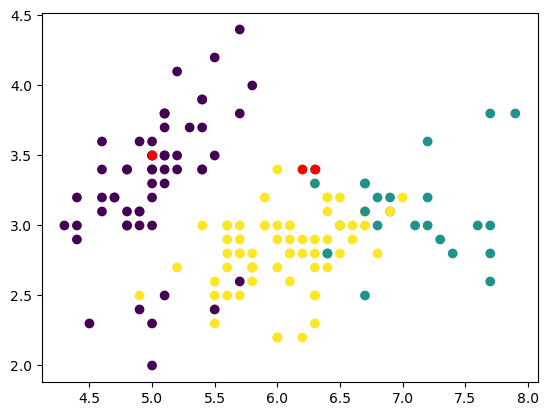

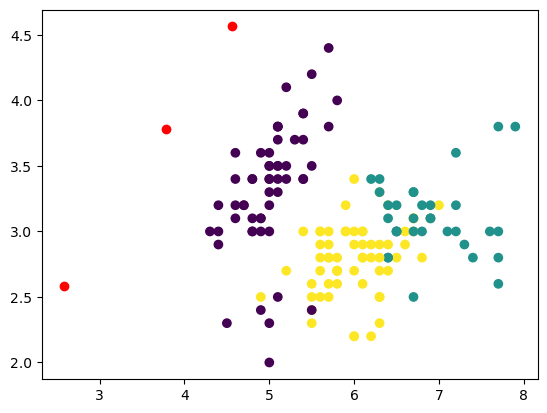

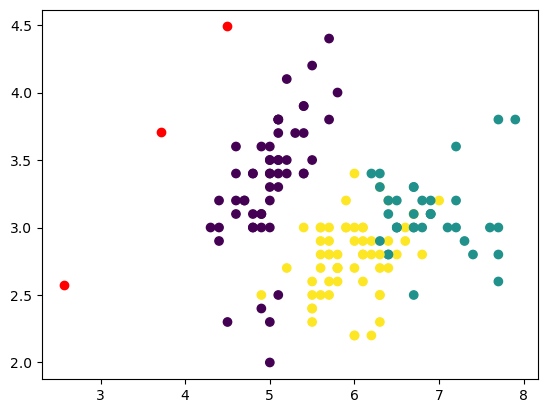

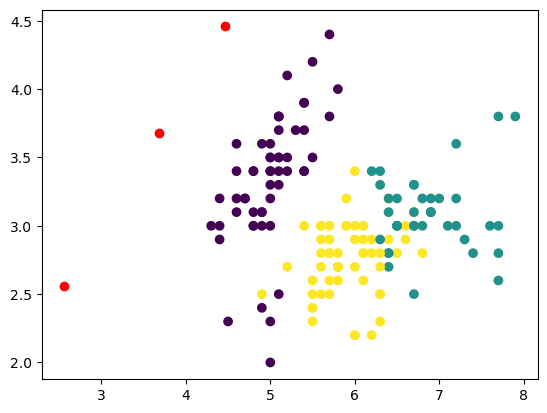

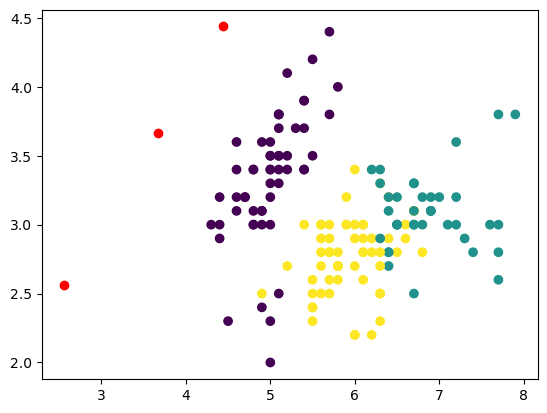

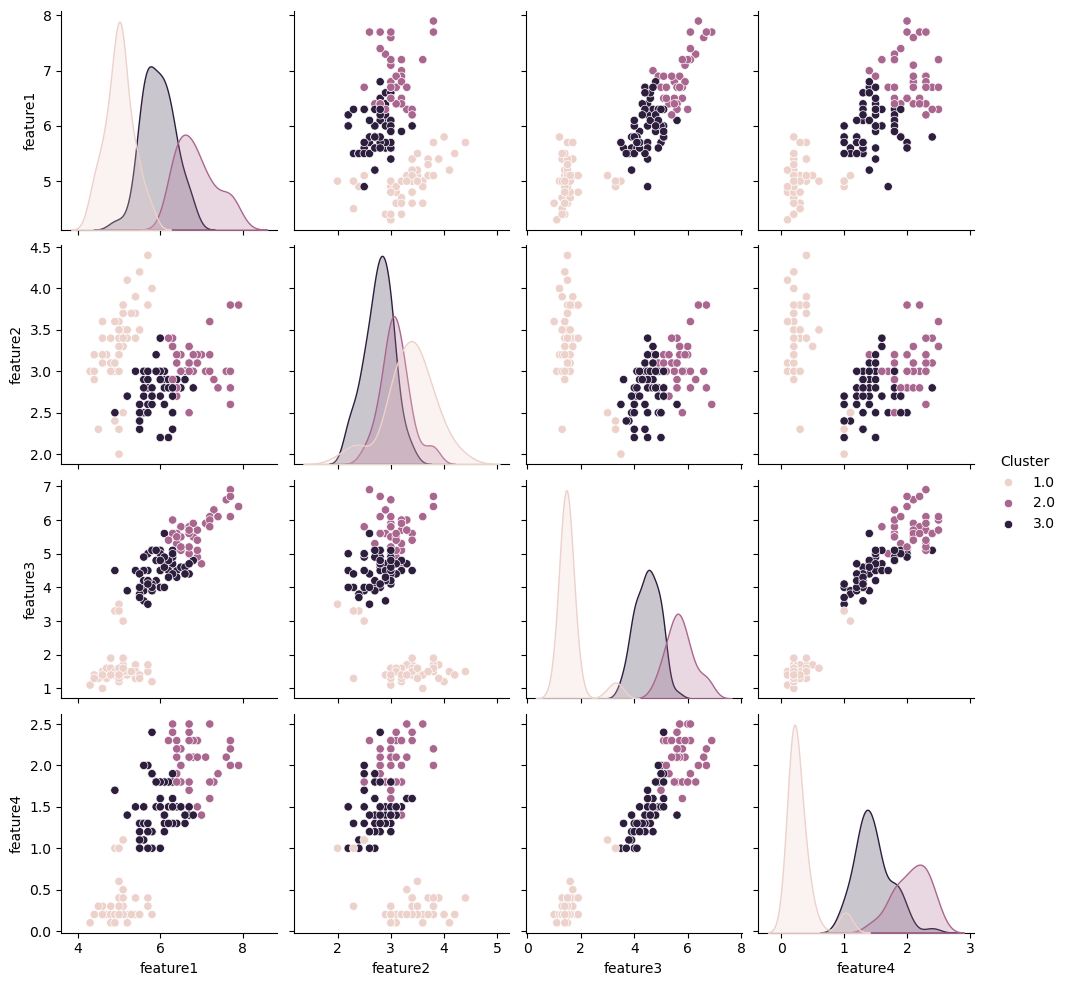

array([[2.5625    , 2.5625    , 2.5625    , 2.5625    ],
       [4.43815789, 4.43815789, 4.43815789, 4.43815789],
       [3.66637931, 3.66637931, 3.66637931, 3.66637931]])

In [11]:
dataset = load_iris()

l = Kmeans()
f = l.fit_predict(dataset.data)
f

In [ ]:
from sklearn.cluster import KMeans
k = KMeans(n_clusters = 3)
df = pd.DataFrame(dataset.data, columns=['feature1', 'feature2', 'feature3', 'feature4'])
df['Cluster'] = k.fit_predict(dataset.data)
sns.pairplot(df, hue="Cluster")
plt.show()